# Análise de Redes Sociais: Rede de Colaboração do K-Pop
Neste notebook, exploraremos uma rede de colaborações entre ídolos do K-pop. 
Nosso objetivo é construir o grafo da rede, analisar a formação de grupos (como o grau de homofilia baseado em gênero) e identificar os nós mais centrais e influentes usando métricas de centralidade.

## 1. Importação de Bibliotecas e Carregamento dos Dados
Primeiro, vamos importar os pacotes necessários que incluem `pandas` para manipulação de dados, `networkx` para criação e análise do grafo, e `matplotlib` para visualização.

In [20]:
import pandas as pd
import networkx as nx
from networkx.algorithms import community
import matplotlib.pyplot as plt

### 1.1 Carregamento e Criação do Grafo
Carregamos as arestas (conexões) a partir de um arquivo CSV, onde `source` e `target` representam os cantores colaborando entre si.

In [21]:
df = pd.read_csv("../Social Network Analysis/data/kpop_collab_network.csv")
df

,source,target
0,NCT U,NCT
1,SEULGI,Kassy
2,Whee In,GSoul
3,Eric Nam,Loco
4,CHEN,BAEKHYUN
...,...,...
402,SOYOU,KIHYUN
403,HEIZE,Crush
404,JOY,Paul Kim
405,Chantel 姚焯菲,Gigi炎明熹


Agora vamos criar um grafo não direcionado a partir do nosso DataFrame utilizando a função `from_pandas_edgelist`.

In [22]:
G = nx.from_pandas_edgelist(
    df,
    source="source",
    target="target"
)

## 📊 Resumo Estatístico da Rede

Antes de mergulhar nas análises, vamos examinar as **propriedades fundamentais** dessa rede.  
Essas métricas são o ponto de partida de qualquer análise de SNA:

| Propriedade | Descrição |
|---|---|
| **Nós** | Total de artistas |
| **Arestas** | Total de colaborações |
| **Densidade** | Proporção de conexões existentes vs. possíveis |
| **Grau Médio** | Média de colaborações por artista |
| **Clustering Médio** | Tendência de vizinhos se conectarem entre si |
| **Componentes** | Partes desconexas da rede |


In [23]:
import networkx as nx
import numpy as np

# Métricas globais da rede
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
degrees = [d for _, d in G.degree()]
avg_degree = np.mean(degrees)
max_degree = max(degrees)
avg_clustering = nx.average_clustering(G)
num_components = nx.number_connected_components(G)
largest_cc = max(nx.connected_components(G), key=len)

print("=" * 50)
print("   RESUMO ESTATÍSTICO DA REDE K-POP")
print("=" * 50)
print(f"  Nós (artistas)        : {num_nodes}")
print(f"  Arestas (colaborações): {num_edges}")
print(f"  Densidade             : {density:.4f}")
print(f"  Grau Médio            : {avg_degree:.2f}")
print(f"  Grau Máximo           : {max_degree}")
print(f"  Clustering Médio      : {avg_clustering:.4f}")
print(f"  Componentes Conectadas: {num_components}")
print(f"  Tamanho da Maior CC   : {len(largest_cc)} nós")
print("=" * 50)


   RESUMO ESTATÍSTICO DA REDE K-POP
  Nós (artistas)        : 255
  Arestas (colaborações): 407
  Densidade             : 0.0126
  Grau Médio            : 3.19
  Grau Máximo           : 20
  Clustering Médio      : 0.0996
  Componentes Conectadas: 26
  Tamanho da Maior CC   : 186 nós


### 1.2 Visualização Inicial da Rede
Abaixo, desenhamos a rede de forma simplificada para termos uma ideia inicial da densidade e da forma como as comunidades se agrupam.

/tmp/ipykernel_294432/4226537107.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(communities))
/home/carolina/miniconda3/envs/teste2/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24373 (\N{CJK UNIFIED IDEOGRAPH-5F35}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/carolina/miniconda3/envs/teste2/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/carolina/miniconda3/envs/teste2/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36070 (\N{CJK UNIFIED IDEOGRAPH-8CE6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

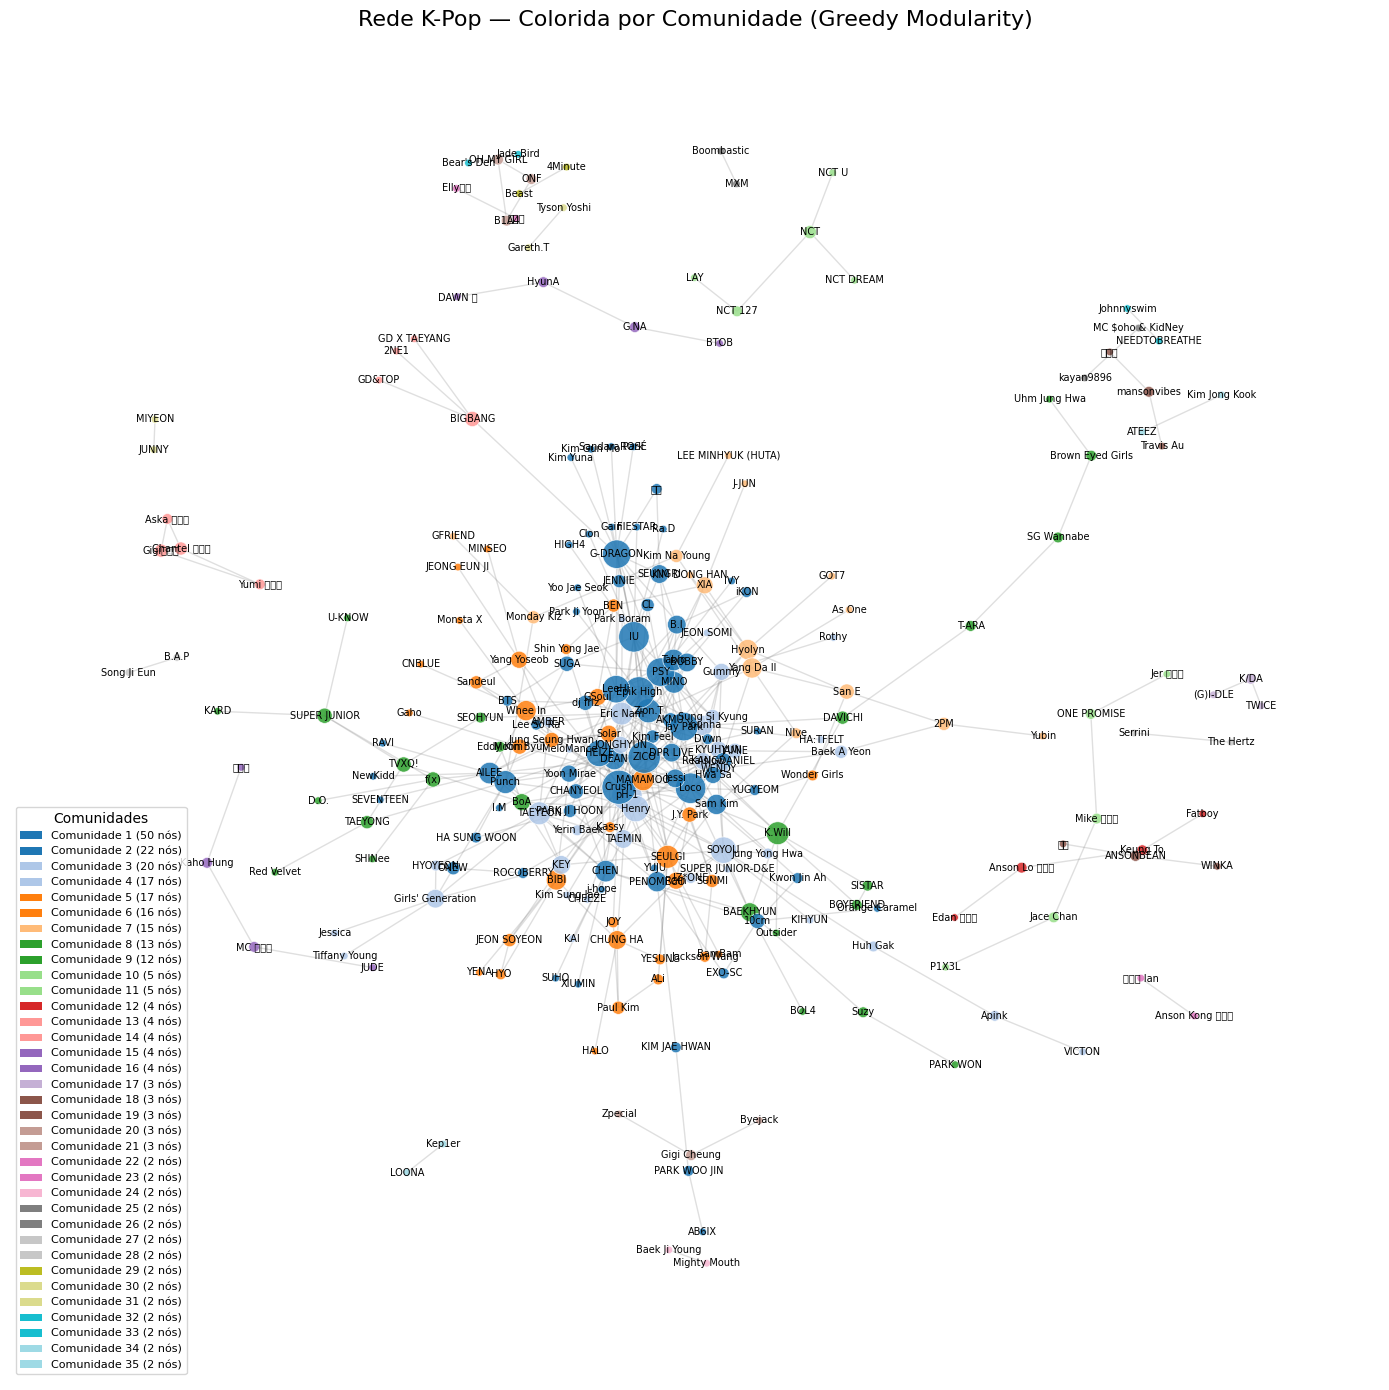

In [24]:
from networkx.algorithms import community as nx_community
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Detectar comunidades
communities = list(nx_community.greedy_modularity_communities(G))

# Criar mapa de cor: cada nó recebe o índice da sua comunidade
node_community = {}
for idx, comm in enumerate(communities):
    for node in comm:
        node_community[node] = idx

# Paleta de cores proporcional ao número de comunidades
cmap = cm.get_cmap("tab20", len(communities))
node_colors = [cmap(node_community[node]) for node in G.nodes()]

# Tamanho dos nós proporcional ao grau
d = dict(G.degree())

plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.15, seed=42)

nx.draw_networkx_nodes(
    G, pos,
    node_size=[v * 30 for v in d.values()],
    node_color=node_colors,
    alpha=0.85,
    edgecolors='white',
    linewidths=0.5
)
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=7, font_color='black')

# Legenda das comunidades
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=cmap(i), label=f"Comunidade {i+1} ({len(communities[i])} nós)")
    for i in range(len(communities))
]
plt.legend(
    handles=legend_handles,
    loc='lower left',
    fontsize=8,
    title="Comunidades",
    framealpha=0.8
)

plt.title("Rede K-Pop — Colorida por Comunidade (Greedy Modularity)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


## 2. Centralidade de Grau e Ranking de Colaboração
A **Centralidade de Grau** (*Degree Centrality*) mede quantas conexões diretas cada nó possui na rede.
Aqui calculamos o grau absoluto de cada artista (número de colaborações diretas) e ordenamos os artistas em um ranking para identificar os mais colaborativos da rede K-Pop.

### 3.1 Ranking de Grau (Degree)
Calculamos o grau absoluto de cada nó (número de conexões diretas) e criamos um ranking para identificar os membros mais colaborativos.

In [25]:
degree = dict(G.degree())
ranking = sorted(degree.items(), key=lambda x: x[1], reverse=True)

print(ranking)

[('Crush', 20), ('ZICO', 18), ('Epik High', 17), ('Loco', 16), ('pH-1', 16), ('IU', 16), ('G-DRAGON', 14), ('PSY', 14), ('Jay Park', 14), ('LeeHi', 13), ('Henry', 12), ('HEIZE', 12), ('SOYOU', 12), ('Zion.T', 10), ('SEULGI', 9), ('Eric Nam', 9), ('Punch', 9), ('K.Will', 9), ('TAEYEON', 9), ('CHEN', 8), ('MINO', 8), ('DEAN', 8), ('Tablo', 8), ('AILEE', 8), ('MAMAMOO', 8), ('Whee In', 7), ('Younha', 7), ('Hyolyn', 7), ('BIBI', 7), ('PENOMECO', 7), ('Yang Da Il', 7), ('Sam Kim', 7), ('BAEKHYUN', 6), ('BOBBY', 6), ('SEUNGRI', 6), ('DPR LIVE', 6), ('CHUNG HA', 6), ('B.I', 6), ('WENDY', 6), ('TAEMIN', 6), ('Jessi', 6), ("Girls' Generation", 6), ('KEY', 6), ('GSoul', 5), ('Yoon Mirae', 5), ('Yang Yoseob', 5), ('Gummy', 5), ('KYUHYUN', 5), ('KANGDANIEL', 5), ('XIA', 5), ('Solar', 5), ('Realslow', 5), ('Rain', 5), ('Hwa Sa', 5), ('BoA', 5), ('JONGHYUN', 5), ('J.Y. Park', 4), ('Jung Seung Hwan', 4), ('San E', 4), ('f(x)', 4), ('SUPER JUNIOR', 4), ('10cm', 4), ('AKMU', 4), ('JAMIE', 4), ('dj friz

## 3. Análise de Propriedades dos Nós: Centralidade
As métricas de centralidade nos ajudam a entender a influência e a importância dos nós (atores) dentro da rede.

### 3.1 Centralidade de Grau (Degree Centrality)
A centralidade de grau ('Degree Centrality') avalia simplesmente a proporção de conexões diretas que um nó possui em relação ao total possível na rede. Nós com alta centralidade de grau são frequentemente vistos como "hubs" muito bem conectados e influentes de maneira direta.

In [26]:
for pos, (node, deg) in enumerate(ranking, start=1):
    print(f"{pos}º lugar: {node} → grau {deg}")

1º lugar: Crush → grau 20
2º lugar: ZICO → grau 18
3º lugar: Epik High → grau 17
4º lugar: Loco → grau 16
5º lugar: pH-1 → grau 16
6º lugar: IU → grau 16
7º lugar: G-DRAGON → grau 14
8º lugar: PSY → grau 14
9º lugar: Jay Park → grau 14
10º lugar: LeeHi → grau 13
11º lugar: Henry → grau 12
12º lugar: HEIZE → grau 12
13º lugar: SOYOU → grau 12
14º lugar: Zion.T → grau 10
15º lugar: SEULGI → grau 9
16º lugar: Eric Nam → grau 9
17º lugar: Punch → grau 9
18º lugar: K.Will → grau 9
19º lugar: TAEYEON → grau 9
20º lugar: CHEN → grau 8
21º lugar: MINO → grau 8
22º lugar: DEAN → grau 8
23º lugar: Tablo → grau 8
24º lugar: AILEE → grau 8
25º lugar: MAMAMOO → grau 8
26º lugar: Whee In → grau 7
27º lugar: Younha → grau 7
28º lugar: Hyolyn → grau 7
29º lugar: BIBI → grau 7
30º lugar: PENOMECO → grau 7
31º lugar: Yang Da Il → grau 7
32º lugar: Sam Kim → grau 7
33º lugar: BAEKHYUN → grau 6
34º lugar: BOBBY → grau 6
35º lugar: SEUNGRI → grau 6
36º lugar: DPR LIVE → grau 6
37º lugar: CHUNG HA → grau 6


### 3.2 PageRank
O **PageRank** é um algoritmo originalmente desenvolvido para ranquear resultados de busca no Google. Na análise de redes como a nossa, o algoritmo não contabiliza apenas o número de conexões (seu grau), mas também leva em consideração a *influência* dessas conexões. Ou seja, um nó ganha maior importância (PageRank maior) se ele próprio estiver conectado a outros nós que também são altamente centrais e influentes.

### 3.2 Centralidade de Grau (Degree Centrality)
Normalizamos a métrica de grau para obter uma medida de centralidade entre 0 e 1, facilitando a comparação entre diferentes grafos.

In [27]:
degree_centrality = nx.degree_centrality(G)
print(degree_centrality)

{'NCT U': 0.003937007874015748, 'NCT': 0.011811023622047244, 'SEULGI': 0.03543307086614173, 'Kassy': 0.007874015748031496, 'Whee In': 0.027559055118110236, 'GSoul': 0.01968503937007874, 'Eric Nam': 0.03543307086614173, 'Loco': 0.06299212598425197, 'CHEN': 0.031496062992125984, 'BAEKHYUN': 0.023622047244094488, 'MINO': 0.031496062992125984, 'Zion.T': 0.03937007874015748, 'pH-1': 0.06299212598425197, 'J.Y. Park': 0.015748031496062992, 'Jung Seung Hwan': 0.015748031496062992, 'Henry': 0.047244094488188976, 'JENNIE': 0.011811023622047244, 'G-DRAGON': 0.05511811023622047, 'CNBLUE': 0.003937007874015748, 'JUDE': 0.003937007874015748, 'MC 張天賦': 0.007874015748031496, 'IU': 0.06299212598425197, 'DEAN': 0.031496062992125984, 'PSY': 0.05511811023622047, 'Tablo': 0.031496062992125984, 'BamBam': 0.003937007874015748, 'BOBBY': 0.023622047244094488, '2PM': 0.011811023622047244, 'San E': 0.015748031496062992, 'f(x)': 0.015748031496062992, 'SUPER JUNIOR': 0.015748031496062992, 'Jace Chan': 0.0078740157

## 4. Propriedades Globais da Rede
Por fim, extraímos e visualizamos algumas métricas consolidadas sobre toda a forma do grafo. Elas revelam a conectividade, distância média dos caminhos, e estrutura macro da comunidade observada.

### 3.3 Centralidade de Intermediação (Betweenness Centrality)
A centralidade de intermediação mede a frequência com que um nó atua como uma 'ponte' no caminho mais curto entre outros dois nós. Nós com alta intermediação são fundamentais para o fluxo de informações na rede.

In [28]:
betweenness = nx.betweenness_centrality(G)
print(betweenness)

{'NCT U': 0.0, 'NCT': 0.00015561295944726278, 'SEULGI': 0.024033279287577404, 'Kassy': 0.0003357698947627677, 'Whee In': 0.02042326878699853, 'GSoul': 0.008386146824772402, 'Eric Nam': 0.029323282315633938, 'Loco': 0.048592495090254643, 'CHEN': 0.029034197585180638, 'BAEKHYUN': 0.023882274404859325, 'MINO': 0.004384637609423749, 'Zion.T': 0.022611954540214627, 'pH-1': 0.0688922464441172, 'J.Y. Park': 0.005395848493246645, 'Jung Seung Hwan': 0.004065874370253319, 'Henry': 0.03538949112762613, 'JENNIE': 0.00014539649441317216, 'G-DRAGON': 0.053399481938486364, 'CNBLUE': 0.0, 'JUDE': 0.0, 'MC 張天賦': 6.224518377890511e-05, 'IU': 0.048482543201476797, 'DEAN': 0.011101924772088817, 'PSY': 0.032465756701020164, 'Tablo': 0.009989341578860951, 'BamBam': 0.0, 'BOBBY': 0.004276214431399894, '2PM': 0.005910180199807039, 'San E': 0.008263334610308759, 'f(x)': 0.02266179817298675, 'SUPER JUNIOR': 0.012177823136476775, 'Jace Chan': 9.336777566835766e-05, 'P1X3L': 0.0, 'SEUNGRI': 0.0022171508180884964,

## 4. Detecção de Comunidades
A detecção de comunidades busca encontrar grupos de nós que estão mais densamente conectados entre si do que com o resto da rede. Utilizamos o algoritmo *Greedy Modularity* para particionar os artistas em comunidades ('panelinhas').

In [29]:
communities = community.greedy_modularity_communities(G)

for i, c in enumerate(communities):
    print(f"Comunidade {i+1}: {list(c)}")

Comunidade 1: ['G-DRAGON', 'Jay Park', 'SURAN', 'Crush', 'dj friz', 'Kim Yuna', 'DPR LIVE', 'FIESTAR', 'Loco', 'Jessi', 'HEIZE', 'BTS', 'JENNIE', 'ZICO', 'PSY', 'Sandara Park', 'Hwa Sa', 'Sam Kim', 'AKMU', 'Epik High', 'Tablo', 'IVY', 'LeeHi', 'HIGH4', 'DEAN', 'ROSÉ', 'BOBBY', 'iKON', 'Dvwn', 'Ra.D', '태양', 'SEUNGRI', 'B.I', 'YUJU', 'KANGDANIEL', 'Zion.T', 'MINO', 'Yoo Jae Seok', 'Park Ji Yoon', 'Lee So Ra', 'Kim Feel', 'Kim Gun Mo', 'YUGYEOM', 'SUGA', 'Clon', 'Gain', 'IU', 'CL', 'j-hope', 'I.M']
Comunidade 2: ['ROCOBERRY', 'PARK JI HOON', 'EXO-SC', 'AB6IX', 'Kwon Jin Ah', 'ONEW', 'PENOMECO', 'Yoon Mirae', 'SUHO', 'Orange Caramel', '10cm', 'HA SUNG WOON', 'SEVENTEEN', 'NewKidd', 'RAVI', 'AILEE', 'KIM JAE HWAN', 'PARK WOO JIN', 'CHANYEOL', 'XIUMIN', 'Punch', 'CHEN']
Comunidade 3: ['Sung Si Kyung', 'Yerin Baek', 'pH-1', 'SUPER JUNIOR-D&E', 'Rothy', 'KYUHYUN', 'Realslow', 'Younha', 'IZ*ONE', 'SOYOU', 'KIHYUN', 'HA:TFELT', 'Huh Gak', 'Gummy', 'CHEEZE', 'Kim Sung Jae', 'VICTON', 'Jung Yong H

### 4.1 Principais Pontes da Rede (Top Betweenness)
Elegemos os 10 nós com a maior centralidade de intermediação. Estes costumam ser os membros que conectam diferentes comunidades ou gêneros musicais.

In [30]:
bet = nx.betweenness_centrality(G)

In [31]:
ranking_bet = sorted(bet.items(), key=lambda x: x[1], reverse=True)

for i, (node, val) in enumerate(ranking_bet[:10], 1):
    print(f"{i}º {node} → {val:.3f}")

1º ZICO → 0.078
2º pH-1 → 0.069
3º Crush → 0.066
4º G-DRAGON → 0.053
5º Jay Park → 0.052
6º Loco → 0.049
7º IU → 0.048
8º SOYOU → 0.047
9º HEIZE → 0.037
10º Punch → 0.036


### 4.2 Centralidade de Autovetor (Eigenvector Centrality)
Uma centralidade alta de autovetor significa que um nó está conectado a outros nós que também possuem alta centralidade. É uma medida de 'influência' dentro da rede.

In [32]:
eig = nx.eigenvector_centrality(G, max_iter=1000)

ranking_eig = sorted(eig.items(), key=lambda x: x[1], reverse=True)
ranking_eig[:10]

[('Crush', 0.33441379522980486),
 ('Epik High', 0.304800867548749),
 ('ZICO', 0.2670843325529921),
 ('Jay Park', 0.23974638677449936),
 ('Loco', 0.21915646891851895),
 ('IU', 0.21265160429245902),
 ('Zion.T', 0.20528842952153933),
 ('PSY', 0.19419344220690674),
 ('LeeHi', 0.192381115245617),
 ('pH-1', 0.17844555994298145)]

### 4.3 Visualização do Subgrafo (Top 30 Intermediação)
Vamos filtrar a rede para visualizar apenas a elite dos 30 nós que atuam mais fortemente como intermediários e formadores de opinião.

In [33]:
top_nodes = [n for n, _ in ranking_bet[:30]]

subG = G.subgraph(top_nodes)

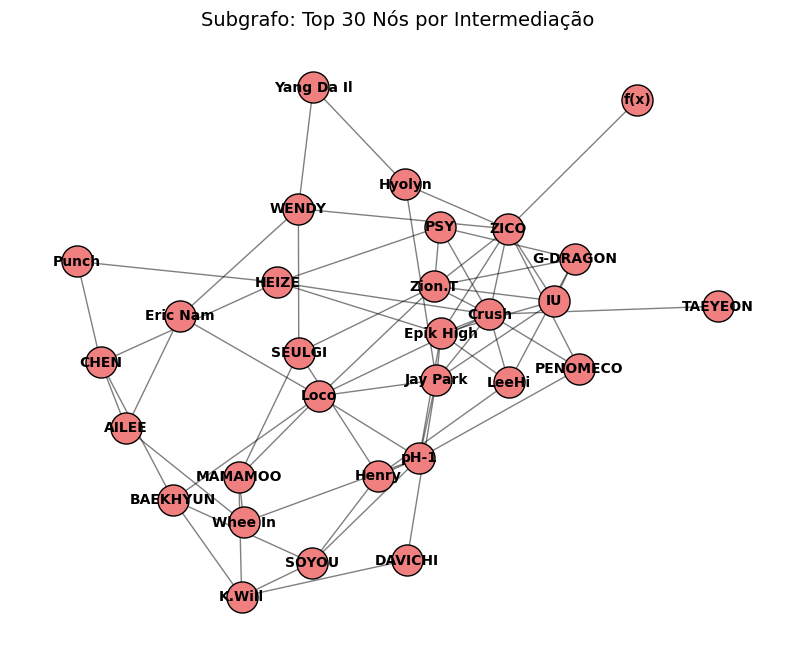

In [34]:
plt.figure(figsize=(10, 8))
pos_sub = nx.spring_layout(subG, seed=42)
nx.draw_networkx_nodes(subG, pos_sub, node_color='lightcoral', node_size=500, edgecolors='black')
nx.draw_networkx_edges(subG, pos_sub, alpha=0.5)
nx.draw_networkx_labels(subG, pos_sub, font_size=10, font_weight='bold')
plt.title("Subgrafo: Top 30 Nós por Intermediação", fontsize=14)
plt.axis('off')
plt.show()

### 4.4 Distribuição do Tamanho das Comunidades

In [35]:
for i, comm in enumerate(communities):
    print(f"Comunidade {i+1}: {len(comm)} nós")

Comunidade 1: 50 nós
Comunidade 2: 22 nós
Comunidade 3: 20 nós
Comunidade 4: 17 nós
Comunidade 5: 17 nós
Comunidade 6: 16 nós
Comunidade 7: 15 nós
Comunidade 8: 13 nós
Comunidade 9: 12 nós
Comunidade 10: 5 nós
Comunidade 11: 5 nós
Comunidade 12: 4 nós
Comunidade 13: 4 nós
Comunidade 14: 4 nós
Comunidade 15: 4 nós
Comunidade 16: 4 nós
Comunidade 17: 3 nós
Comunidade 18: 3 nós
Comunidade 19: 3 nós
Comunidade 20: 3 nós
Comunidade 21: 3 nós
Comunidade 22: 2 nós
Comunidade 23: 2 nós
Comunidade 24: 2 nós
Comunidade 25: 2 nós
Comunidade 26: 2 nós
Comunidade 27: 2 nós
Comunidade 28: 2 nós
Comunidade 29: 2 nós
Comunidade 30: 2 nós
Comunidade 31: 2 nós
Comunidade 32: 2 nós
Comunidade 33: 2 nós
Comunidade 34: 2 nós
Comunidade 35: 2 nós


### 4.5 Explorando uma Comunidade Específica
Podemos isolar e analisar especificamente uma das comunidades geradas para entender sua composição individual.

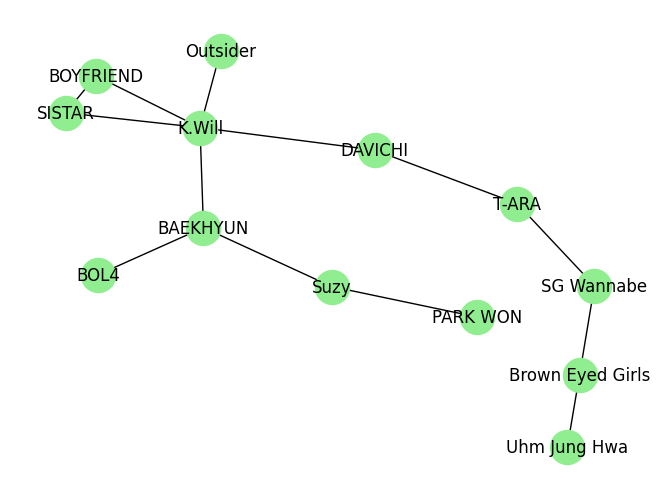

In [36]:
comm0 = list(communities[7])
sub = G.subgraph(comm0)

nx.draw(sub, with_labels=True, node_color='lightgreen', node_size=600)
plt.show()

## 5. Hubs e Métricas Estruturais
A **Densidade** indica quão conectada a rede está em comparação com o máximo de conexões possíveis. Redes sociais reais geralmente são muito esparsas (baixa densidade).

In [37]:
nx.density(G)

0.012567546703720858

### 5.1 Identificação de Hubs Estritos
Definimos um limite estatístico rigoroso (95º percentil do grau) para revelar os maiores hubs de colaboração do K-Pop.

In [38]:
import numpy as np

threshold = np.percentile(list(degree.values()), 95)

hubs = [n for n, d in degree.items() if d >= threshold]
print(hubs)

['Loco', 'pH-1', 'Henry', 'G-DRAGON', 'IU', 'PSY', 'HEIZE', 'Epik High', 'Crush', 'SOYOU', 'LeeHi', 'Jay Park', 'ZICO']


## 6. Tabela Resumo: O Perfil de Influência
Unificamos os principais indicadores de rede num único DataFrame `pandas` para compararmos quais nós reinam absolutos no ecossistema e ordenamos pelo fator de intermediação ("Ponte de Colaborações").

## 📈 Distribuição de Graus

A **distribuição de graus** é um dos conceitos mais importantes em SNA.  
Ela mostra quantos nós possuem cada nível de conectividade.

Redes sociais reais frequentemente seguem uma distribuição **power-law**  
(*escala livre*): poucos nós muito conectados (hubs) e muitos pouco conectados.


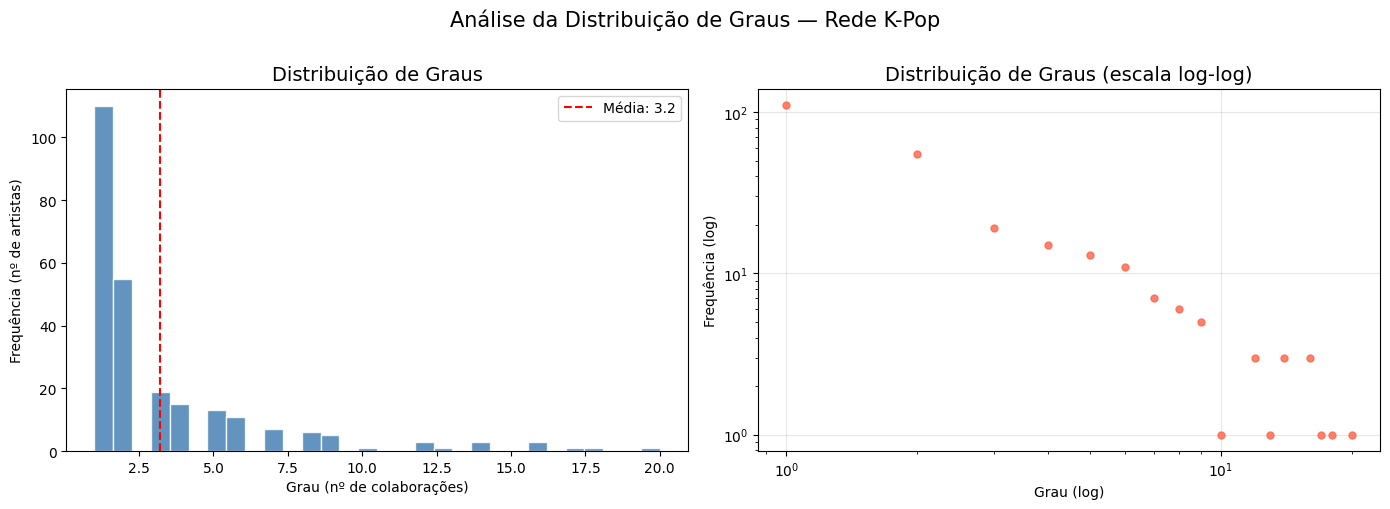

Grau mínimo: 1 | Máximo: 20 | Médio: 3.19 | Mediana: 2


In [39]:
graus = sorted([d for _, d in G.degree()], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma simples
axes[0].hist(graus, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição de Graus', fontsize=14)
axes[0].set_xlabel('Grau (nº de colaborações)')
axes[0].set_ylabel('Frequência (nº de artistas)')
axes[0].axvline(np.mean(graus), color='red', linestyle='--', label=f'Média: {np.mean(graus):.1f}')
axes[0].legend()

# Escala log-log para verificar power-law
from collections import Counter
degree_counts = Counter(graus)
x = sorted(degree_counts.keys())
y = [degree_counts[k] for k in x]
axes[1].loglog(x, y, 'o', markersize=5, color='tomato', alpha=0.8)
axes[1].set_title('Distribuição de Graus (escala log-log)', fontsize=14)
axes[1].set_xlabel('Grau (log)')
axes[1].set_ylabel('Frequência (log)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análise da Distribuição de Graus — Rede K-Pop', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print(f"Grau mínimo: {min(graus)} | Máximo: {max(graus)} | Médio: {np.mean(graus):.2f} | Mediana: {np.median(graus):.0f}")


## 🏆 Tabela Comparativa: Top 10 Artistas por Centralidade

Cada métrica de centralidade revela um papel diferente na rede:

| Métrica | O que mede | Significa... |
|---|---|---|
| **Degree** | Conexões diretas | Artista mais colaborativo |
| **Betweenness** | Passagem em caminhos mais curtos | Artista-ponte entre grupos |
| **Eigenvector** | Conexão com nós importantes | Artista conectado aos mais influentes |
| **PageRank** | Influência propagada pela rede | Influência global |
| **Clustering** | Coesão dos vizinhos | Pertence a um grupo fechado? |


In [40]:
import pandas as pd

# Calcular todas as métricas (reutilizando se já calculadas)
degree_c   = nx.degree_centrality(G)
between_c  = nx.betweenness_centrality(G)
eigen_c    = nx.eigenvector_centrality(G, max_iter=1000)
pagerank_c = nx.pagerank(G)
clust_c    = nx.clustering(G)
degree_abs = dict(G.degree())

df_metrics = pd.DataFrame({
    'Artista'     : list(G.nodes()),
    'Grau'        : [degree_abs[n] for n in G.nodes()],
    'Degree C.'   : [round(degree_c[n], 4) for n in G.nodes()],
    'Betweenness' : [round(between_c[n], 4) for n in G.nodes()],
    'Eigenvector' : [round(eigen_c[n], 4) for n in G.nodes()],
    'PageRank'    : [round(pagerank_c[n], 4) for n in G.nodes()],
    'Clustering'  : [round(clust_c[n], 4) for n in G.nodes()],
})

# Top 10 por betweenness (artistas-ponte mais relevantes)
top10 = df_metrics.sort_values('Betweenness', ascending=False).head(10).reset_index(drop=True)
top10.index = top10.index + 1
top10


,Artista,Grau,Degree C.,Betweenness,Eigenvector,PageRank,Clustering
1,ZICO,18,0.0709,0.0784,0.2671,0.0148,0.1046
2,pH-1,16,0.0630,0.0689,0.1784,0.0139,0.0667
3,Crush,20,0.0787,0.0659,0.3344,0.0157,0.1316
4,G-DRAGON,14,0.0551,0.0534,0.1358,0.0136,0.0769
5,Jay Park,14,0.0551,0.0524,0.2397,0.0110,0.1429
6,Loco,16,0.0630,0.0486,0.2192,0.0129,0.0917
7,IU,16,0.0630,0.0485,0.2127,0.0142,0.0667
8,SOYOU,12,0.0472,0.0467,0.0803,0.0110,0.0758
9,HEIZE,12,0.0472,0.0370,0.1657,0.0099,0.1061
10,Punch,9,0.0354,0.0361,0.0421,0.0088,0.0556


## 🔗 Coeficiente de Clustering

O **coeficiente de clustering** de um nó mede a proporção de pares de vizinhos  
que também estão conectados entre si — ou seja, o quão "fechado" é o grupo ao redor de um artista.

- **Valor 1.0** → todos os vizinhos colaboram entre si (clique perfeito)  
- **Valor 0.0** → nenhum vizinho se conecta diretamente a outro  

Nós com alto *betweenness* mas baixo *clustering* são tipicamente **pontes** entre comunidades.


/tmp/ipykernel_294432/4260826257.py:25: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_294432/4260826257.py:25: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_294432/4260826257.py:25: UserWarning: Glyph 37758 (\N{CJK UNIFIED IDEOGRAPH-937E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_294432/4260826257.py:25: UserWarning: Glyph 26580 (\N{CJK UNIFIED IDEOGRAPH-67D4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_294432/4260826257.py:25: UserWarning: Glyph 32654 (\N{CJK UNIFIED IDEOGRAPH-7F8E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_294432/4260826257.py:25: UserWarning: Glyph 24373 (\N{CJK UNIFIED IDEOGRAPH-5F35}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_294432/4260826257.py:25: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929

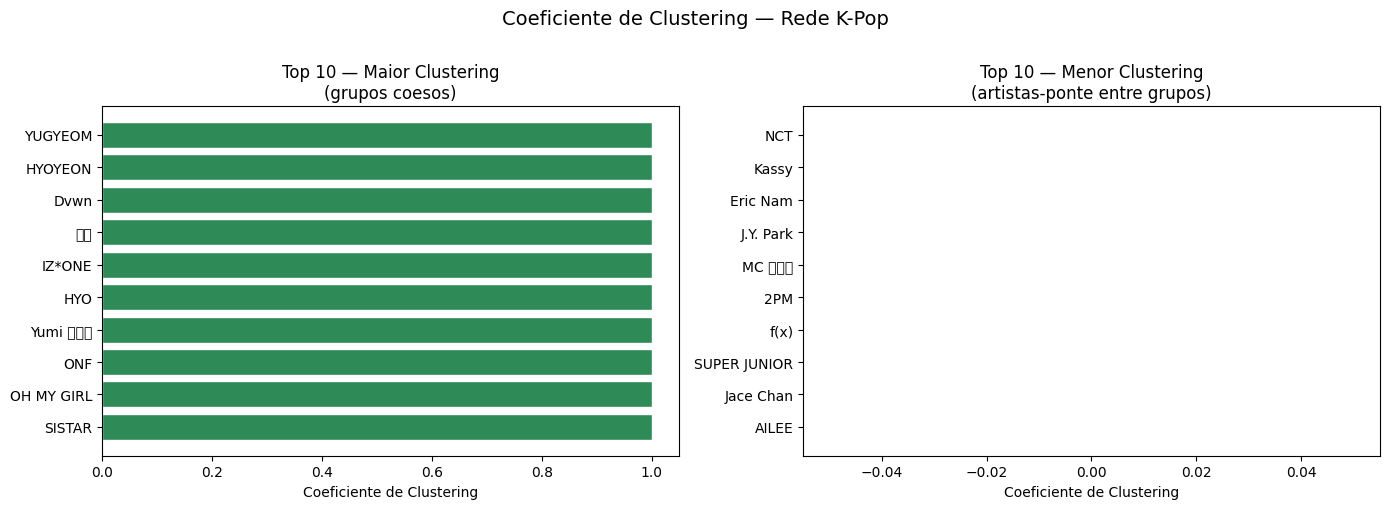

In [41]:
# Top 10 com maior e menor clustering (excluindo nós com grau < 2)
clust_filtrado = {n: c for n, c in clust_c.items() if degree_abs[n] >= 2}

top_clust  = sorted(clust_filtrado.items(), key=lambda x: x[1], reverse=True)[:10]
bot_clust  = sorted(clust_filtrado.items(), key=lambda x: x[1])[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Alto clustering
nomes_top, vals_top = zip(*top_clust)
axes[0].barh(list(nomes_top), list(vals_top), color='seagreen', edgecolor='white')
axes[0].set_title('Top 10 — Maior Clustering\n(grupos coesos)', fontsize=12)
axes[0].set_xlabel('Coeficiente de Clustering')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1.05)

# Baixo clustering (artistas-ponte)
nomes_bot, vals_bot = zip(*bot_clust)
axes[1].barh(list(nomes_bot), list(vals_bot), color='tomato', edgecolor='white')
axes[1].set_title('Top 10 — Menor Clustering\n(artistas-ponte entre grupos)', fontsize=12)
axes[1].set_xlabel('Coeficiente de Clustering')
axes[1].invert_yaxis()

plt.suptitle('Coeficiente de Clustering — Rede K-Pop', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 🗺️ Visualização da Maior Comunidade

Isolamos a maior comunidade detectada pelo algoritmo *Greedy Modularity*  
para uma análise mais detalhada. Nessa visualização:

- O **tamanho** dos nós representa o grau (número de colaborações)
- A **intensidade da cor** representa o *betweenness* (importância como ponte)
- As **arestas cinzas** ligam artistas que colaboraram juntos


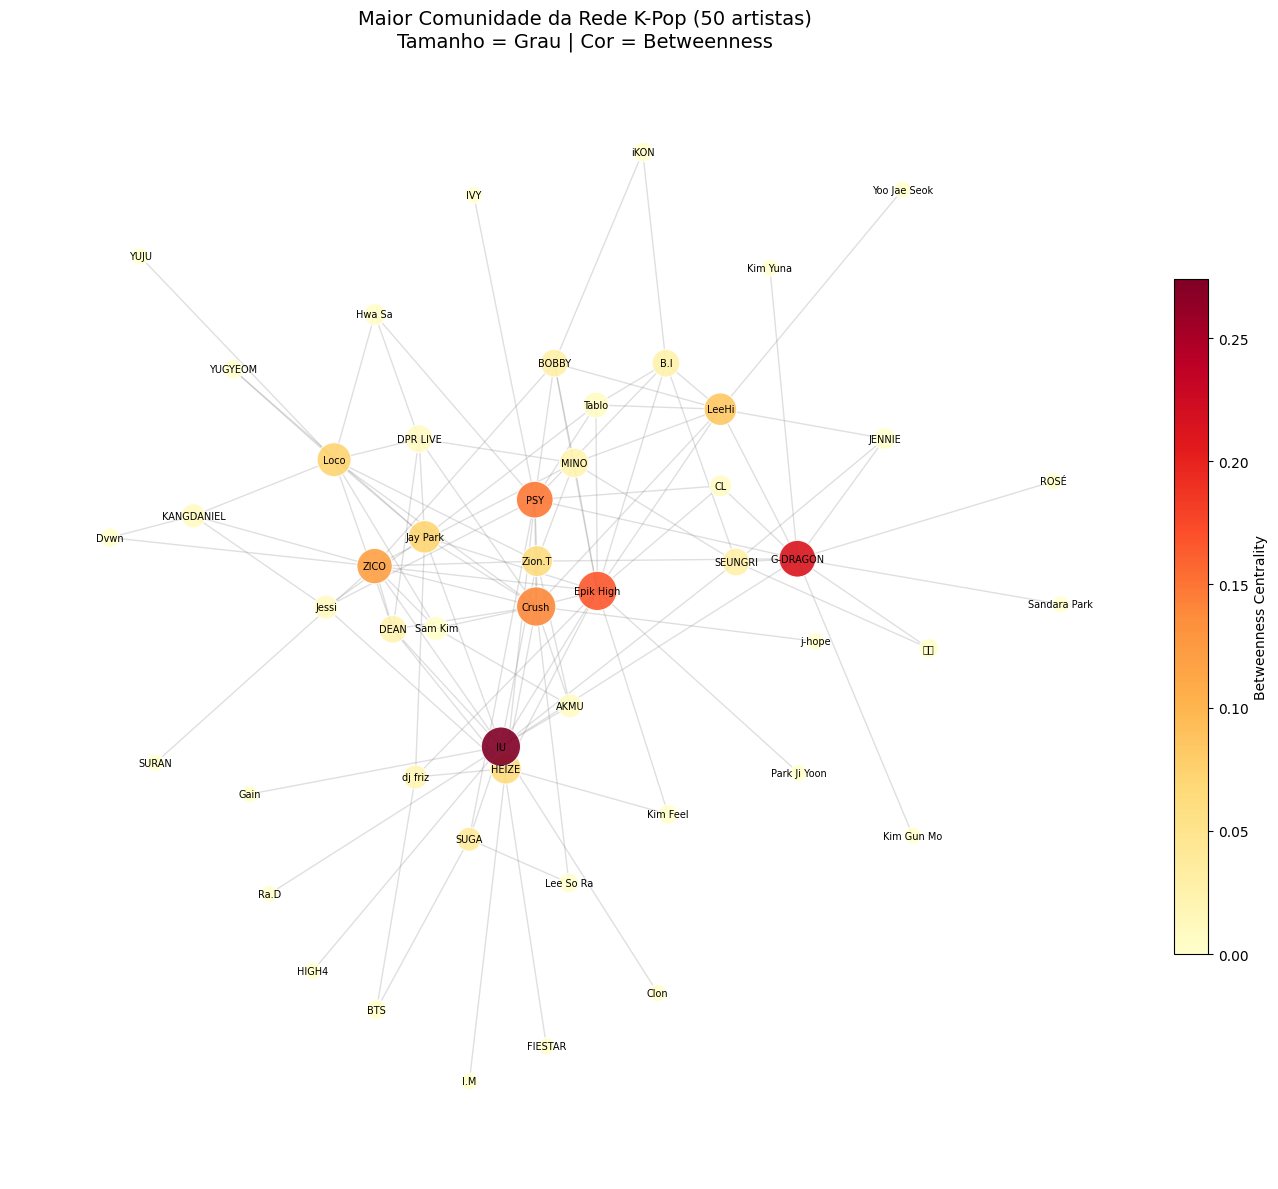

In [42]:
from networkx.algorithms import community as nx_community

# Detectar comunidades e obter a maior
comms = list(nx_community.greedy_modularity_communities(G))
maior_comm = max(comms, key=len)
subG = G.subgraph(maior_comm)

# Métricas no subgrafo
sub_degree  = dict(subG.degree())
sub_between = nx.betweenness_centrality(subG)

node_sizes  = [sub_degree[n] * 50 + 100 for n in subG.nodes()]
node_colors = [sub_between[n] for n in subG.nodes()]

pos_sub = nx.spring_layout(subG, k=0.4, seed=42)

fig, ax = plt.subplots(figsize=(14, 12))

nodes = nx.draw_networkx_nodes(
    subG, pos_sub,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.YlOrRd,
    alpha=0.9,
    edgecolors='white',
    linewidths=0.8,
    ax=ax
)
nx.draw_networkx_edges(subG, pos_sub, alpha=0.25, edge_color='gray', ax=ax)
nx.draw_networkx_labels(subG, pos_sub, font_size=7, ax=ax)

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
     norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label('Betweenness Centrality', fontsize=10)

ax.set_title(
    f'Maior Comunidade da Rede K-Pop ({len(maior_comm)} artistas)\n'
    'Tamanho = Grau | Cor = Betweenness',
    fontsize=14
)
ax.axis('off')
plt.tight_layout()
plt.show()


In [43]:

df_metrics = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [degree[n] for n in G.nodes()],
    "betweenness": [bet[n] for n in G.nodes()],
    "eigenvector": [eig[n] for n in G.nodes()]
})

df_metrics.sort_values("betweenness", ascending=False).head(10)

,node,degree,betweenness,eigenvector
74,ZICO,18,0.078354,0.267084
12,pH-1,16,0.068892,0.178446
42,Crush,20,0.065871,0.334414
17,G-DRAGON,14,0.053399,0.135790
66,Jay Park,14,0.052351,0.239746
7,Loco,16,0.048592,0.219156
21,IU,16,0.048483,0.212652
45,SOYOU,12,0.046736,0.080311
34,HEIZE,12,0.036987,0.165683
49,Punch,9,0.036114,0.042094
